# Importing required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the cleaned dataset

In [2]:
df = pd.read_csv("cleaned_flights.csv")

# Display first 5 rows
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,MONTH,DAY_OF_WEEK,HOUR,ROUTE
0,2022-07-22,UNITED AIR LINES INC.,United Air Lines Inc.: UA,UA,19977.0,459.0,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,680.0,0.0,0.0,0.0,0.0,0.0,7,4,10.0,DEN-MSP
1,2019-07-31,SOUTHWEST AIRLINES CO.,Southwest Airlines Co.: WN,WN,19393.0,665.0,DAL,"Dallas, TX",OKC,"Oklahoma City, OK",...,181.0,141.0,0.0,0.0,0.0,0.0,7,2,12.0,DAL-OKC
2,2021-06-11,DELTA AIR LINES INC.,Delta Air Lines Inc.: DL,DL,19790.0,2820.0,ATL,"Atlanta, GA",BDL,"Hartford, CT",...,859.0,60.0,0.0,0.0,0.0,0.0,6,4,19.0,ATL-BDL
3,2021-08-05,SOUTHWEST AIRLINES CO.,Southwest Airlines Co.: WN,WN,19393.0,430.0,MDW,"Chicago, IL",BNA,"Nashville, TN",...,395.0,0.0,0.0,0.0,0.0,0.0,8,3,8.0,MDW-BNA
4,2022-05-01,SOUTHWEST AIRLINES CO.,Southwest Airlines Co.: WN,WN,19393.0,1011.0,BWI,"Baltimore, MD",BDL,"Hartford, CT",...,283.0,0.0,0.0,0.0,0.0,0.0,5,6,17.0,BWI-BDL


#Check Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3944 entries, 0 to 3943
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   FL_DATE                  3944 non-null   object 
 1   AIRLINE                  3944 non-null   object 
 2   AIRLINE_DOT              3944 non-null   object 
 3   AIRLINE_CODE             3944 non-null   object 
 4   DOT_CODE                 3944 non-null   float64
 5   FL_NUMBER                3944 non-null   float64
 6   ORIGIN                   3944 non-null   object 
 7   ORIGIN_CITY              3944 non-null   object 
 8   DEST                     3944 non-null   object 
 9   DEST_CITY                3944 non-null   object 
 10  CRS_DEP_TIME             3944 non-null   float64
 11  DEP_TIME                 3936 non-null   object 
 12  DEP_DELAY                3944 non-null   float64
 13  TAXI_OUT                 3944 non-null   float64
 14  WHEELS_OFF              

#Basic Dataset Overview

In [ ]:
df.shape

(3944, 36)

In [ ]:
df.describe()

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,...,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,MONTH,DAY_OF_WEEK,HOUR
count,3944.000000,3944.000000,3944.000000,3944.000000,3944.000000,3944.000000,3944.000000,3944.000000,3944.000000,3944.000000,...,3944.000000,3944.000000,3944.000000,3944.000000,3944.000000,3944.000000,3944.000000,3944.000000,3944.000000,3936.000000
mean,19930.472110,2331.518509,1453.436866,46.806034,18.574544,1518.381339,1566.098377,7.955122,1600.093053,1558.941937,...,115.272819,825.109280,16.580882,2.852688,6.844067,0.119168,16.535243,6.354209,3.063134,14.781504
std,392.980103,1685.843637,464.609568,78.988634,11.560162,498.099785,588.798275,6.870585,523.966336,602.871963,...,67.293122,559.351142,54.228890,31.562230,26.830581,3.351501,46.170265,3.291801,1.997417,4.756754
min,19393.000000,1.000000,23.000000,0.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,9.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,19687.000000,955.500000,1100.000000,10.000000,12.000000,1133.000000,1224.750000,4.000000,1237.000000,1220.000000,...,66.000000,406.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,11.000000
50%,19805.000000,1987.000000,1512.000000,24.000000,15.000000,1556.000000,1703.000000,6.000000,1705.000000,1703.500000,...,101.000000,704.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,3.000000,15.000000
75%,20368.000000,3455.250000,1830.000000,54.000000,21.000000,1925.000000,2029.000000,9.000000,2019.250000,2032.000000,...,145.000000,1062.000000,15.000000,0.000000,2.000000,0.000000,14.250000,9.000000,5.000000,19.000000
max,20452.000000,7429.000000,2359.000000,1180.000000,143.000000,2400.000000,2400.000000,164.000000,2359.000000,2400.000000,...,507.000000,4243.000000,1022.000000,1180.000000,1124.000000,154.000000,1049.000000,12.000000,6.000000,23.000000


#Route & Airport-Level Analysis

**1.Average Delay by Route**

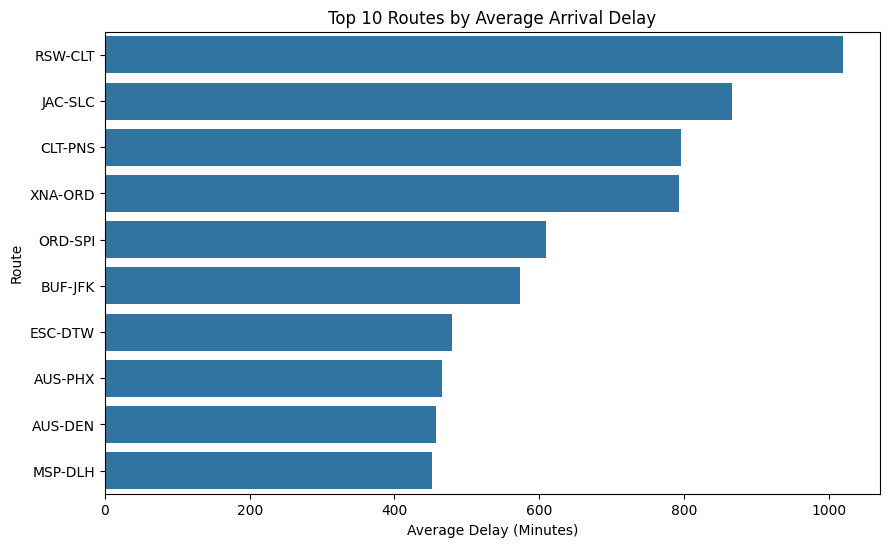

In [ ]:
route_delay = df.groupby('ROUTE')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=route_delay.values, y=route_delay.index)
plt.title("Top 10 Routes by Average Arrival Delay")
plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Route")
plt.show()

### Insights: Route Delay Analysis

- The visualization shows the **top 10 flight routes with the highest average arrival delays**.
- Certain routes consistently experience **higher delays compared to others**, indicating possible congestion or operational challenges.
- Routes with higher average delays such as RSW-CLT may be affected by **busy airports, long-distance travel, or frequent weather disruptions**.
- Identifying these routes helps airlines and analysts **focus on improving scheduling, resource allocation, and traffic management**.
- This analysis can support **better decision-making to reduce delays and improve overall flight performance**.

**2.Top 10 Airports vs Monthly Average Arrival Delay Heatmap**

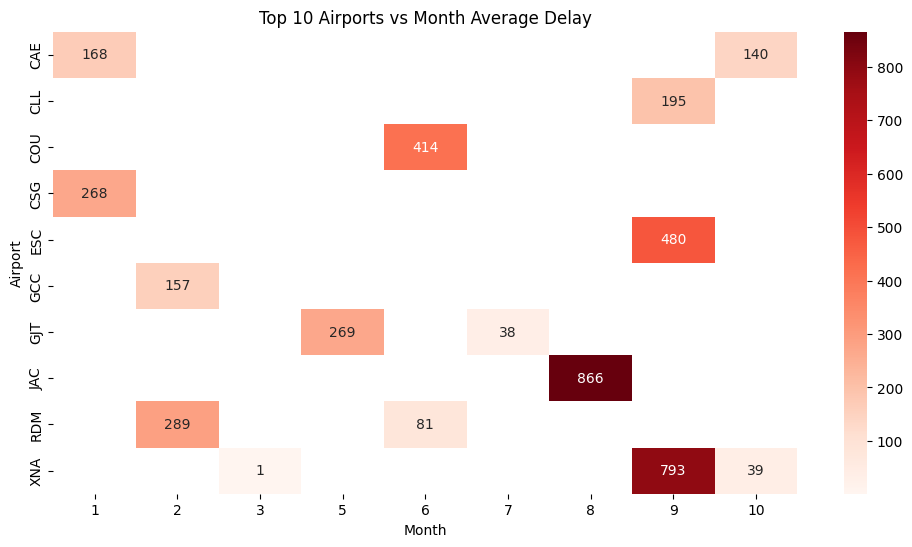

In [ ]:
top_airports = df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(10).index
df_top = df[df['ORIGIN'].isin(top_airports)]
airport_delay = df_top.groupby(['ORIGIN','MONTH'])['ARR_DELAY'].mean().unstack()
plt.figure(figsize=(12,6))
sns.heatmap(airport_delay, cmap='Reds', annot=True,fmt=".0f")
plt.title("Top 10 Airports vs Month Average Delay")
plt.xlabel("Month")
plt.ylabel("Airport")
plt.show()

### ✈️ Insights: Average Arrival Delay by Airport and Month

This heatmap shows the **average arrival delays (in minutes)** for the top 10 airports across different months. Darker shades of red indicate **higher delays**, while lighter shades represent **lower delays**.

From the visualization, we can observe that **JAC airport recorded the highest delay**, reaching **866 minutes in month 8**, which stands out as the most significant delay in the dataset. Similarly, **XNA airport experienced a large delay of 793 minutes in month 9**, and **ESC airport also had a notable delay of 480 minutes during the same month**.

Another noticeable spike appears at **COU airport in month 6**, where the average delay reached **414 minutes**. Moderate delays can be seen at **RDM (289 minutes in month 2)** and **GJT (269 minutes in month 5)**.

On the other hand, some airports show **very minimal delays**, such as **XNA in month 3 with only 1 minute**, and **GJT in month 7 with 38 minutes**, indicating relatively smooth operations during those periods.

A small observation from the heatmap is that **many cells appear empty or lightly colored**, which suggests that some airports may not have recorded delays in those months or there were fewer flights in the dataset for those periods.


Overall, the heatmap suggests that **flight delays are not evenly distributed across months**. Instead, certain airports experience **significant spikes in specific months**, which could be influenced by factors such as **weather conditions, seasonal travel demand, or airport congestion**.

**3.Airport Delay Heatmap (Origin vs Destination)**

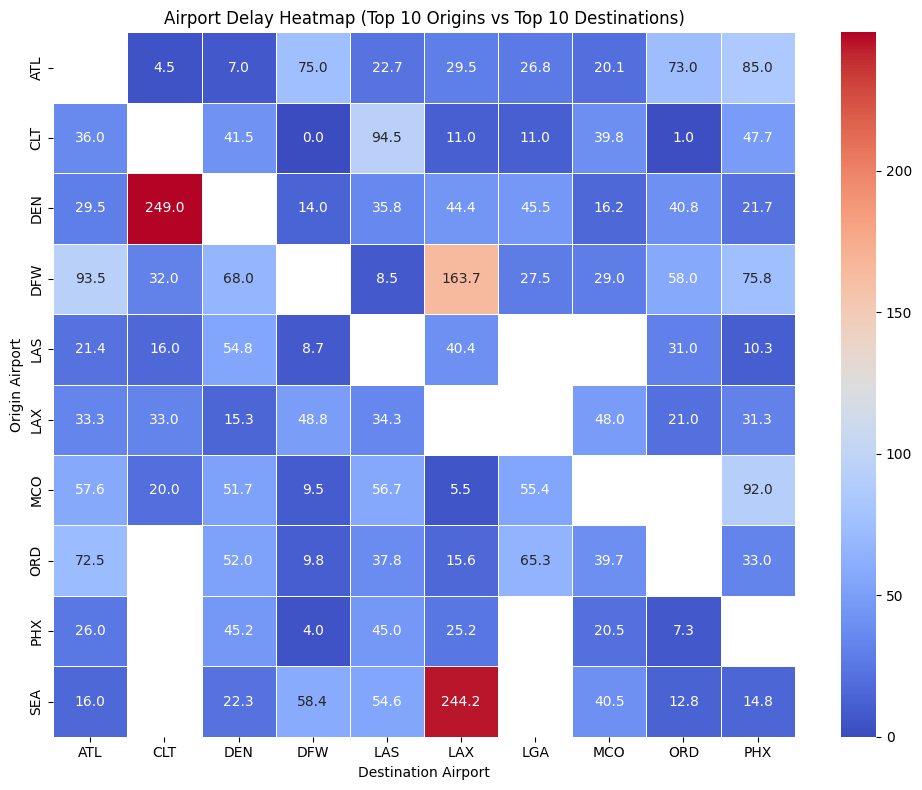

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 origin airports
top_origins = df['ORIGIN'].value_counts().head(10).index

# Top 10 destination airports
top_dest = df['DEST'].value_counts().head(10).index

# Filter dataset
df_filtered = df[df['ORIGIN'].isin(top_origins) & df['DEST'].isin(top_dest)]

# Create pivot table
delay_matrix = df_filtered.pivot_table(
    values='ARR_DELAY',
    index='ORIGIN',
    columns='DEST',
    aggfunc='mean'
)

plt.figure(figsize=(10,8))

sns.heatmap(
    delay_matrix,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt='.1f'
)

plt.title("Airport Delay Heatmap (Top 10 Origins vs Top 10 Destinations)")
plt.xlabel("Destination Airport")
plt.ylabel("Origin Airport")

plt.tight_layout()
plt.show()

### Insights from Airport Delay(Origin vs Destination) Heatmap

* The heatmap highlights the **average arrival delay between major origin and destination airports**. Darker red shades represent routes with **significantly higher delays**, while blue shades indicate **lower delays or more efficient routes**.

* One of the **highest delays is observed between DEN → CLT (≈249 minutes)** and **SEA → LAS (≈244 minutes)**, suggesting these routes may face **operational congestion, weather disruptions, or scheduling inefficiencies**.

* Routes originating from **DFW and SEA** show several moderate to high delay values, indicating these airports may experience **periodic congestion or operational challenges** affecting multiple routes.

* Some routes such as **ATL → CLT** and **PHX → DFW** show **very low delays**, which may indicate **efficient traffic management and better operational performance** between these airport pairs.

* The variation in delays across routes suggests that **airport-specific factors such as traffic density, runway capacity, and regional weather conditions** play a crucial role in flight punctuality.

* Identifying these delay-prone routes can help airlines and airport authorities **optimize scheduling, improve traffic management, and reduce congestion-related delays**.


**4.Busiest Airports**

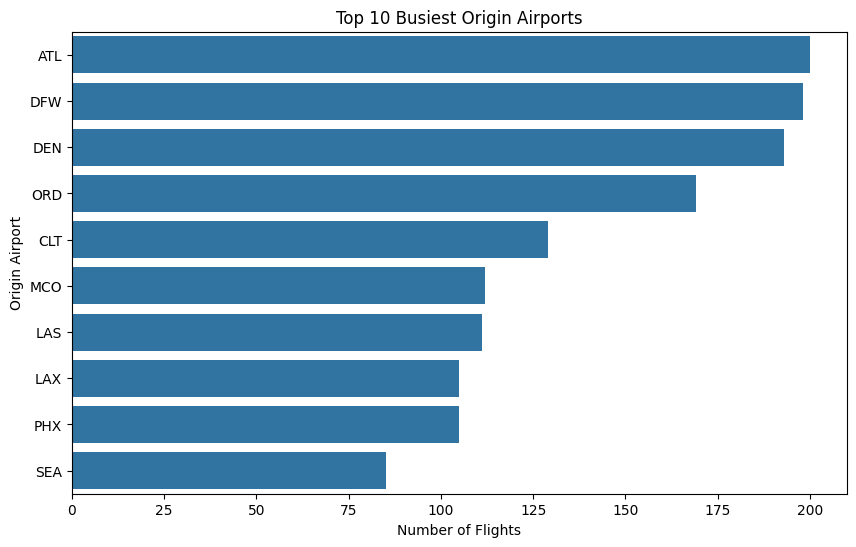

In [ ]:
top_airports = df['ORIGIN'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_airports.values, y=top_airports.index)
plt.title("Top 10 Busiest Origin Airports")
plt.xlabel("Number of Flights")
plt.ylabel("Origin Airport")
plt.show()

### Insights: Top 10 Busiest Origin Airports

* **ATL (Atlanta)** has the highest number of departing flights, making it the busiest origin airport in the dataset.
* **DFW (Dallas/Fort Worth)** and **DEN (Denver)** follow closely behind, indicating they are also major hubs with high flight activity.
* **ORD (Chicago O'Hare)** shows slightly fewer departures than the top three but still represents a major aviation hub.
* There is a noticeable drop in the number of flights after the top four airports, suggesting that flight traffic is concentrated among a few major hubs.
* Airports such as **MCO, LAS, LAX, PHX, and SEA** still handle significant traffic but operate at a lower scale compared to the leading airports.
* Overall, the visualization indicates that **flight departures are heavily concentrated at major hub airports**, which likely serve as key connection points in the flight network.


**5.Route Congestion & Delay Intensity Scatter plot**


We create a scatter quadrant:

**X-axis → Flight Volume**

This shows how many flights operate on that route.

Example:
| Flights | Meaning                 |
| ------- | ----------------------- |
| 1       | route has only 1 flight |
| 5       | route has 5 flights     |
| 10      | route has many flights  |

👉 Points on the right side = more flights

**Y-axis → Average Delay**

This shows average delay in minutes.

Example:
| Delay   | Meaning                 |
| ------- | ----------------------- |
| 20      |  small delay            |
| 100     |  medium delay           |
| 500     | very high delay         |

👉 Points higher up = bigger delays

**Bubble Size → Total Delay Minutes**

The size of the circle shows total delay caused by that route.

Small circle → small impact

Big circle → big impact


**Each Bubble → one flight route**

Example: DFW → LAX, MSP → EWR

**How to Read One Point**

Example:

If a point is:

Flights = 3

Average Delay = 400 minutes

It means:

That route has 3 flights

On average flights are delayed 400 minutes

This is a problematic route.

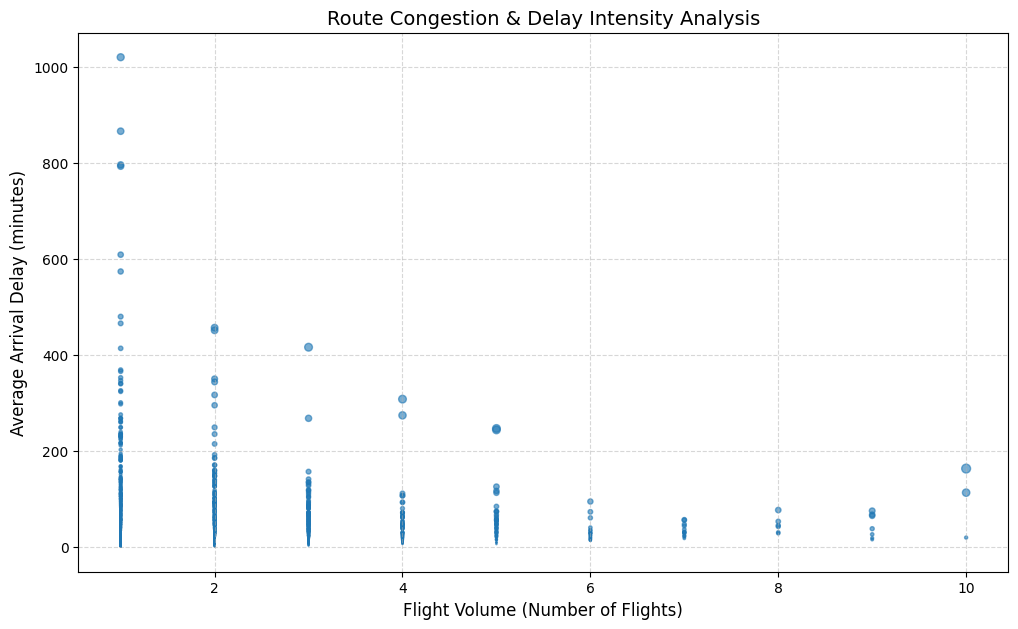

Top 10 Routes Contributing Most to Total Delay:
        ROUTE  FLIGHT_COUNT  AVG_ARR_DELAY  TOTAL_DELAY
673   DFW-LAX            10     163.700000       1637.0
1474  MSP-EWR             3     416.333333       1249.0
231   BOS-CLT             5     247.200000       1236.0
377   CLT-EWR             4     308.250000       1233.0
1970  SEA-LAX             5     244.200000       1221.0
1253  LGA-ORD            10     113.600000       1136.0
2079  SLC-LAX             4     274.500000       1098.0
1874  RSW-CLT             1    1020.000000       1020.0
129   AUS-DEN             2     457.000000        914.0
1471  MSP-DLH             2     451.500000        903.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

route_stats = (
    df.groupby('ROUTE')
      .agg(
          FLIGHT_COUNT=('ROUTE', 'count'),
          AVG_ARR_DELAY=('ARR_DELAY', 'mean'),
          TOTAL_DELAY=('ARR_DELAY', 'sum')
      )
      .reset_index()
)


plt.figure(figsize=(12,7))

scatter = plt.scatter(
    route_stats['FLIGHT_COUNT'],
    route_stats['AVG_ARR_DELAY'],
    s=route_stats['TOTAL_DELAY'] / 40,   # bubble size
    alpha=0.6
)

plt.xlabel("Flight Volume (Number of Flights)", fontsize=12)
plt.ylabel("Average Arrival Delay (minutes)", fontsize=12)
plt.title("Route Congestion & Delay Intensity Analysis", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

high_delay_routes = route_stats.sort_values(
    by='TOTAL_DELAY',
    ascending=False
).head(10)

print("Top 10 Routes Contributing Most to Total Delay:")
print(high_delay_routes[['ROUTE','FLIGHT_COUNT','AVG_ARR_DELAY','TOTAL_DELAY']])

### Insights from the Visualization

1. Most flight routes operate with low flight volume (1–3 flights).

2. Some routes experience extremely high delays (above 800 minutes),
   indicating possible operational or weather disruptions.

3. Routes with higher flight volumes generally show lower average delays,
   suggesting better operational efficiency.

4. A small number of routes contribute disproportionately to total delays
   in the system.

5. Routes such as DFW–LAX and MSP–EWR contribute the highest cumulative delays
   and may require further operational analysis.

Observation 1

Most routes are between 1–3 flights.

Meaning:

👉 Many routes have low traffic.

Observation 2

Some routes have very high delays (800–1000 minutes).

These are outliers.

Possible reasons:

weather problems

airport congestion

operational issues

Observation 3

Routes with more flights (6–10) usually have lower delays.

This suggests:

👉 Busy routes are better managed.

**Understanding the Table Below the Plot**

Top 10 Routes Contributing Most to Total Delay

Example 1

DFW → LAX

10 flights

average delay = 163 minutes

total delay = 1637 minutes

This route causes a lot of delay overall.

Example 2

MSP → EWR

only 3 flights

but delay = 416 minutes

So this route is very inefficient.

**6.AIRPORT OPERATIONAL STRESS INDEX**

This analysis tries to identify which airports experience the most operational pressure.
The stress is calculated using:

Average delay

Number of flights

➡ Airports with many flights AND high delay get very high stress score.

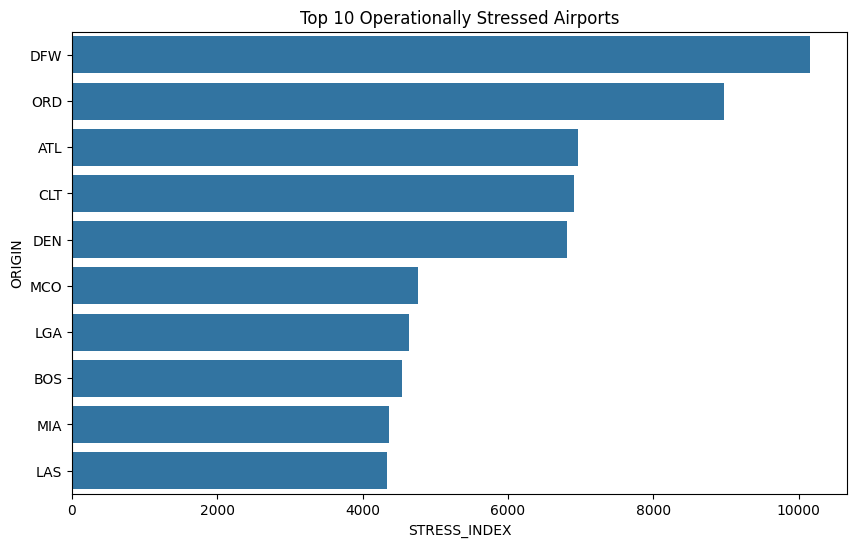

In [ ]:
airport_stats = df.groupby('ORIGIN').agg({
    'ARR_DELAY':'mean',
    'ORIGIN':'count'
}).rename(columns={'ORIGIN':'FLIGHT_COUNT'})

airport_stats['STRESS_INDEX'] = (
    airport_stats['ARR_DELAY'] * airport_stats['FLIGHT_COUNT']
)

top_stress = airport_stats.sort_values(
    'STRESS_INDEX', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_stress['STRESS_INDEX'],
            y=top_stress.index)
plt.title("Top 10 Operationally Stressed Airports")
plt.show()

### Airport Operational Stress Analysis

This visualization identifies the top airports experiencing the highest operational stress.  
The stress index is calculated as the product of the average arrival delay and the total number of flights originating from each airport.

#### Key Observations

1. **DFW (Dallas/Fort Worth)** has the highest operational stress index, indicating that it experiences a combination of high flight traffic and significant delays.

2. **ORD (Chicago O'Hare)** and **ATL (Atlanta)** also show high stress levels, suggesting these airports handle large volumes of flights while facing operational delays.

3. Airports such as **CLT and DEN** appear in the top stressed list due to their relatively high flight activity and delay patterns.

4. The analysis suggests that major hub airports tend to accumulate higher operational stress due to increased traffic volume.

#### Interpretation

Airports with higher stress indices may require operational improvements such as better scheduling, improved air traffic management, or infrastructure enhancements to reduce delays and congestion.

This metric helps identify critical airports where operational efficiency improvements could significantly impact overall network performance.

#Operational Insights

**7.Flight Distance vs Delay (Operational Insight)**

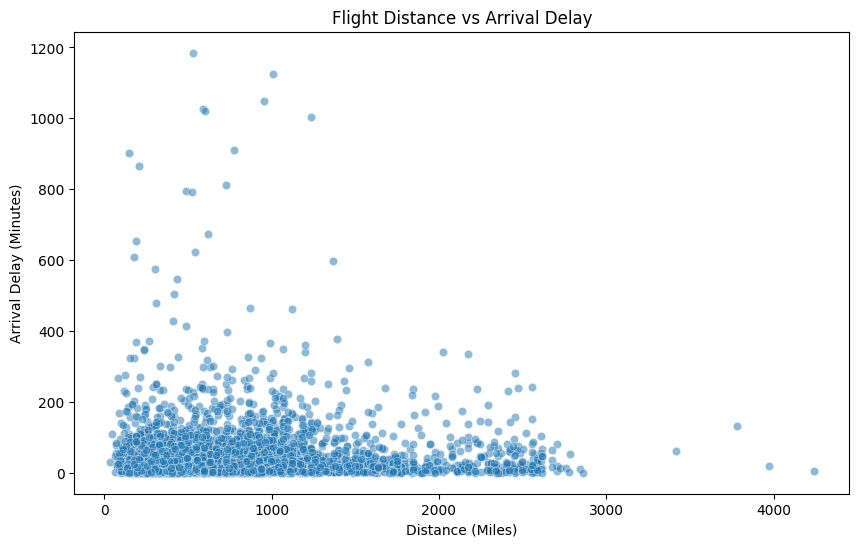

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["DISTANCE"],
    y=df["ARR_DELAY"],
    alpha=0.5
)

plt.title("Flight Distance vs Arrival Delay")
plt.xlabel("Distance (Miles)")
plt.ylabel("Arrival Delay (Minutes)")

plt.show()

### Flight Distance vs Arrival Delay Analysis

This scatter plot visualizes the relationship between flight distance and arrival delay. Each point represents an individual flight, where the x-axis shows the flight distance in miles and the y-axis represents the arrival delay in minutes.

Most flights appear clustered around lower delay values (0–100 minutes), indicating that the majority of flights experience relatively small delays. The points are widely scattered without a clear upward or downward pattern, suggesting that flight distance alone does not strongly influence arrival delays.

A few extreme outliers can be observed with very high delays, which may be caused by unusual operational disruptions such as severe weather conditions, airport congestion, or technical issues.

Short-distance flights also experience large delays.

Long flights sometimes have very small delays.

Overall, the visualization suggests that operational factors and external conditions play a more significant role in flight delays than the distance of the flight itself.

**8.Hourly Flight Traffic (Airport Congestion Insight)**

/tmp/ipykernel_1056/71447036.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


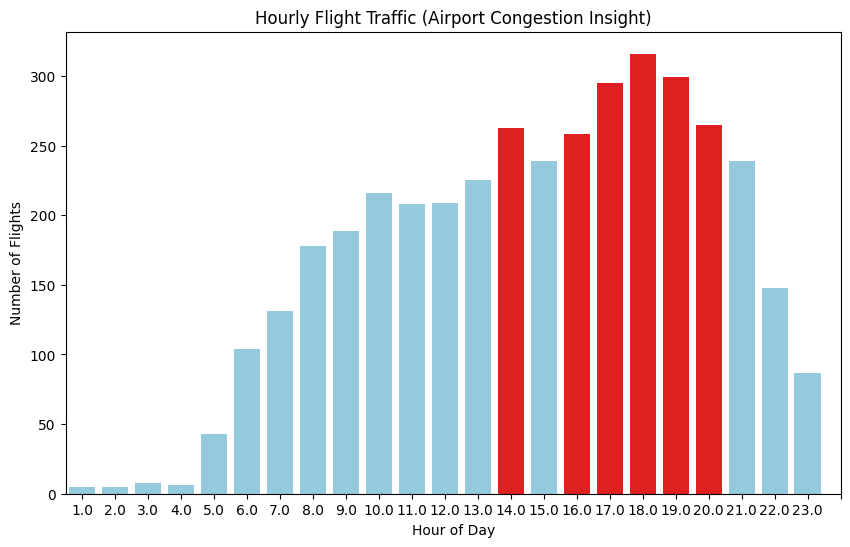

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count flights per hour
hourly_flights = df['HOUR'].value_counts().sort_index()

plt.figure(figsize=(10,6))

# Highlight peak hours
colors = ['skyblue' if v < hourly_flights.max()*0.8 else 'red' for v in hourly_flights.values]

sns.barplot(
    x=hourly_flights.index,
    y=hourly_flights.values,
    palette=colors
)

plt.title("Hourly Flight Traffic (Airport Congestion Insight)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Flights")

plt.xticks(range(24))

plt.show()

### Hourly Flight Traffic Analysis

This visualization shows the distribution of flight traffic across different hours of the day. Each bar represents the total number of flights scheduled during a particular hour.

Peak traffic hours are highlighted in red, while normal traffic hours are shown in blue to make airport congestion periods easier to identify.

A gradual increase in flight activity is observed starting from early morning hours, with traffic rising significantly after 6 AM as airports begin their regular daily operations. Flight activity remains relatively high throughout the daytime hours.

The peak traffic occurs during the late afternoon and evening hours, particularly around 17:00 to 19:00. This indicates that airports experience the highest congestion during this time, likely due to return travel and connecting flights.

In contrast, very few flights are scheduled during late night and early morning hours (1 AM to 5 AM), reflecting reduced airport operations during these periods.

Overall, the analysis highlights clear daily traffic patterns and identifies peak operational hours when airport congestion is highest.

#Checking Flight Cancellation Status

In [ ]:
print("Total Cancelled Flights:", df["CANCELLED"].sum())

Total Cancelled Flights: 0.0


In [ ]:
df['CANCELLED'].describe()

,CANCELLED
count,3944.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


### Cancellation Verification

The dataset was analyzed to identify cancelled flights using the `CANCELLED` column.

The results show that all records contain the value `0`, indicating that none of the flights in this dataset were cancelled.

Therefore, cancellation trend analysis cannot be performed.

#Seasonal Analysis

**Monthly Average Delay Trend**

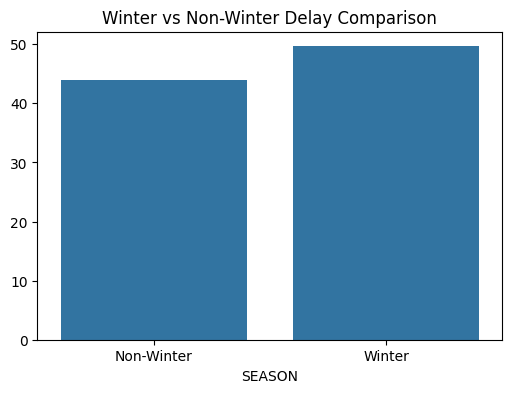

In [ ]:
df['SEASON'] = df['MONTH'].apply(lambda x: 'Winter' if x in [12,1,2] else 'Non-Winter')

season_delay = df.groupby('SEASON')['ARR_DELAY'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=season_delay.index, y=season_delay.values)
plt.title("Winter vs Non-Winter Delay Comparison")
plt.show()

### Winter vs Non-Winter Delay Comparison – Insights

* The visualization compares the **average arrival delay during Winter and Non-Winter months**.
* The **average delay in Winter is around 50 minutes**, which is higher than the **Non-Winter delay of approximately 45 minutes**.
* This indicates that **flights experience slightly more delays during winter months**.
* A possible reason for this pattern is **seasonal weather conditions such as fog, snow, and storms**, which can affect airport operations and flight schedules.
* However, the difference between Winter and Non-Winter delays is **not extremely large**, suggesting that delays occur throughout the year but are **slightly more pronounced in winter**.

**Small Observation:**
Even though winter shows the highest delay, the difference is only about **5 minutes**, which means **factors other than weather (such as airport congestion, air traffic, or operational issues)** may also contribute significantly to flight delays.


**Delay Volatility**

calculate standard deviation per month

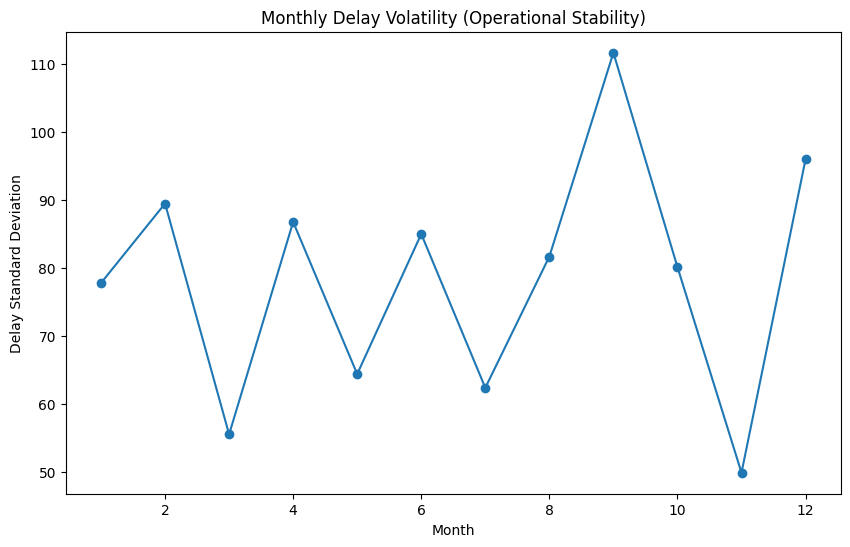

In [ ]:
monthly_volatility = df.groupby('MONTH')['ARR_DELAY'].std()

plt.figure(figsize=(10,6))
plt.plot(monthly_volatility.index,
         monthly_volatility.values,
         marker='o')
plt.title("Monthly Delay Volatility (Operational Stability)")
plt.xlabel("Month")
plt.ylabel("Delay Standard Deviation")
plt.show()

### Monthly Delay Volatility (Operational Stability) – Insights

* This visualization shows the **variation in arrival delays across different months** using standard deviation.
* **Higher standard deviation indicates more unpredictable delays**, while lower values suggest more stable flight operations.

**Key Observations:**

* **September (Month 9)** shows the **highest delay volatility**, indicating that flight delays were highly inconsistent during this month.
* **November (Month 11)** has the **lowest delay volatility**, suggesting that flight operations were relatively more stable.
* Months such as **February, April, June, and December** also show relatively higher variability in delays.
* In contrast, **March and July** have lower volatility, indicating more consistent delay patterns.

**Conclusion:**
The variability in delays changes significantly throughout the year. Months with higher volatility may be influenced by **seasonal weather conditions, increased travel demand, or airport congestion**, leading to more unpredictable flight delays.


**Weather Impact Ratio**

/tmp/ipykernel_782/3441283618.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weather_ratio = df.groupby('MONTH').apply(


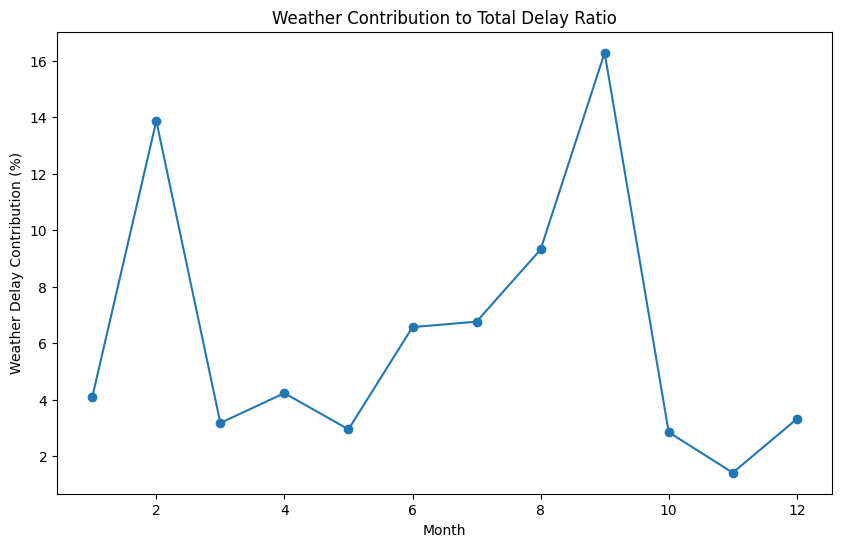

In [3]:
weather_ratio = df.groupby('MONTH').apply(
    lambda x: x['DELAY_DUE_WEATHER'].sum() / x['ARR_DELAY'].sum()
)

weather_ratio = weather_ratio * 100  # convert to percentage

plt.figure(figsize=(10,6))
plt.plot(weather_ratio.index,
         weather_ratio.values,
         marker='o')

plt.title("Weather Contribution to Total Delay Ratio")
plt.xlabel("Month")
plt.ylabel("Weather Delay Contribution (%)")

plt.show()

### Weather Contribution to Total Delay – Insights

• Weather contributes differently to flight delays across months.

• The highest weather impact occurs in **September (~16%)**, indicating weather conditions significantly affected delays during this month.

• **February (~14%)** also shows a high contribution from weather-related delays.

• Most other months show a **low weather contribution (around 3%–7%)**, meaning delays are mostly caused by other factors such as air traffic congestion, carrier issues, or operational delays.

• **November (~1–2%)** has the lowest weather impact, suggesting weather played a very small role in delays during this month.

• Overall, weather is **not the primary cause of delays for most months**, but it becomes a significant factor during certain periods.

**SEASONAL CLUSTERING**

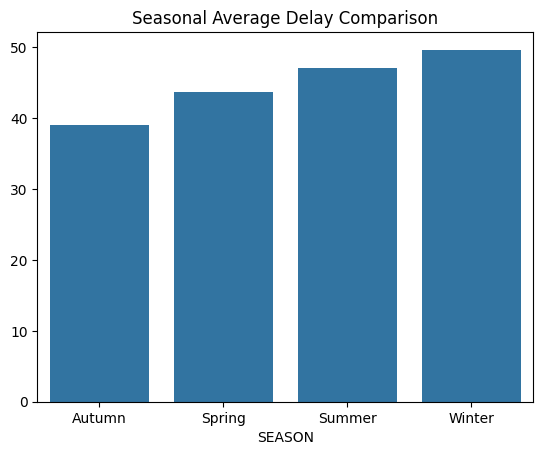

In [ ]:
df['SEASON'] = df['MONTH'].map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',
    9:'Autumn',10:'Autumn',11:'Autumn'
})

season_stats = df.groupby('SEASON')['ARR_DELAY'].mean()

sns.barplot(x=season_stats.index,
            y=season_stats.values)
plt.title("Seasonal Average Delay Comparison")
plt.show()

### Seasonal Average Delay – Insights

• The chart shows the **average flight arrival delay across different seasons**.

• **Winter has the highest average delay (~50 minutes)**, indicating flights are most affected during this season.

• **Summer (~47 minutes) and Spring (~44 minutes)** also experience moderate delays.

• **Autumn has the lowest average delay (~39 minutes)**, suggesting relatively smoother flight operations.

• The higher delays in **Winter are likely due to weather conditions such as snow, fog, and storms**, which can disrupt flight schedules.

• Overall, the analysis suggests that **seasonal factors, especially winter weather, significantly impact flight delays.**

**Monthly Delay Trend**

Shows seasonal delay patterns.

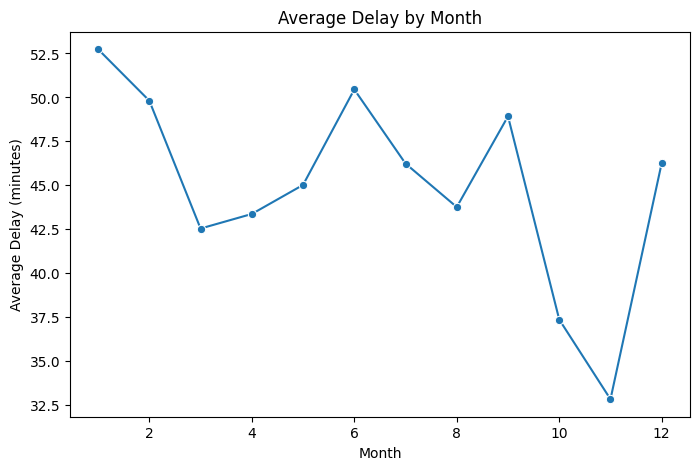

In [ ]:
monthly_delay = df.groupby('MONTH')['ARR_DELAY'].mean()

plt.figure(figsize=(8,5))

sns.lineplot(x=monthly_delay.index, y=monthly_delay.values, marker='o')

plt.title("Average Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")

plt.show()

### Monthly Delay Trend – Insights

• The chart shows how the **average flight arrival delay changes across months**.

• **January (~53 minutes)** has the highest average delay, indicating operational challenges at the start of the year.

• Delays gradually decrease during **March–April (~42–44 minutes)**, suggesting more stable operations.

• Another delay increase is observed in **June (~50 minutes)** and **September (~49 minutes)**.

• **October and November show the lowest delays (~33–37 minutes)**, indicating smoother flight operations during this period.

• Overall, flight delays fluctuate throughout the year, with **higher delays mostly occurring in winter and early summer months**, while **late autumn months experience relatively lower delays.**